In [65]:
%matplotlib inline

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [10]:
df = pd.read_excel("/Users/daliemarcelin/Downloads/2026__28Candidate_29_Personal_Loans_Case_Dataset.xlsx", engine='openpyxl')

In [11]:
print(df.shape)          
print(df.dtypes)         
print(df.head())         
print(df.isnull().sum()) 

(100000, 14)
User ID                       object
applications                   int64
Reason                        object
Loan_Amount                    int64
FICO_score                     int64
Fico_Score_group              object
Employment_Status             object
Employment_Sector             object
Monthly_Gross_Income           int64
Monthly_Housing_Payment        int64
Ever_Bankrupt_or_Foreclose     int64
Lender                        object
Approved                       int64
bounty                         int64
dtype: object
                                User ID  applications  \
0  fffe836d-3176-4766-81c0-8812d1d9a0a6             1   
1  fffd8e45-d5f8-4b06-b1a4-2d4bf527ee51             1   
2  fffba42b-265f-4269-a6d5-c8db7e3bd430             1   
3  fffb63e2-b1d6-4d73-b766-44ba50203c00             1   
4  fffb48e8-fc77-49fe-ab4e-e99a0829a788             1   

                    Reason  Loan_Amount  FICO_score Fico_Score_group  \
0       debt_consolidation        50000 

In [12]:
print(df["Lender"].value_counts())
print(df["Fico_Score_group"].value_counts())
print(df["Employment_Status"].value_counts())
print(df["Approved"].value_counts(normalize=True))

Lender
B    55000
C    27500
A    17500
Name: count, dtype: int64
Fico_Score_group
fair         36475
poor         28475
good         27760
very_good     5102
excellent     2188
Name: count, dtype: int64
Employment_Status
full_time     76530
part_time     17064
unemployed     6406
Name: count, dtype: int64
Approved
0    0.89022
1    0.10978
Name: proportion, dtype: float64


In [13]:
df["dti"] = df["Monthly_Housing_Payment"] / df["Monthly_Gross_Income"]

In [14]:
print(df.groupby("Approved")["dti"].describe())

            count      mean       std       min       25%       50%       75%  \
Approved                                                                        
0         89022.0  0.348527  0.198004  0.017048  0.205784  0.301110  0.449453   
1         10978.0  0.271320  0.194311  0.020758  0.151740  0.223147  0.338486   

               max  
Approved            
0         1.623881  
1         1.625124  


In [15]:
numeric_cols = ["FICO_score", "Loan_Amount", "Monthly_Gross_Income",
                "Monthly_Housing_Payment", "Ever_Bankrupt_or_Foreclose", "dti"]
correlations = df[numeric_cols].corrwith(df["Approved"]).sort_values(ascending=False)
print(correlations)

FICO_score                    0.269673
Monthly_Gross_Income          0.171829
Monthly_Housing_Payment      -0.027644
Ever_Bankrupt_or_Foreclose   -0.035311
Loan_Amount                  -0.040170
dti                          -0.121246
dtype: float64


In [16]:
fico_order = ["poor", "fair", "good", "very_good", "excellent"]
fico_rates = df.groupby("Fico_Score_group")["Approved"].mean().reindex(fico_order)
print(fico_rates)

Fico_Score_group
poor         0.027849
fair         0.064373
good         0.180620
very_good    0.356723
excellent    0.458410
Name: Approved, dtype: float64


In [17]:
print(df.groupby("Employment_Status")["Approved"].mean())

Employment_Status
full_time     0.120724
part_time     0.081282
unemployed    0.054948
Name: Approved, dtype: float64


In [18]:
print(df.groupby("Ever_Bankrupt_or_Foreclose")["Approved"].mean())

Ever_Bankrupt_or_Foreclose
0    0.111453
1    0.036955
Name: Approved, dtype: float64


In [19]:
df["Employment_Sector_clean"] = df["Employment_Sector"].fillna("unknown")

In [22]:
lender_summary = df.groupby("Lender").agg(
    Applications=("Approved", "count"),
    Approvals=("Approved", "sum"),
    Approval_Rate=("Approved", "mean"),
    Total_Revenue=("bounty", "sum"),
    Revenue_Per_App=("bounty", lambda x: x.sum() / len(x))
)
print(lender_summary.round(3))

        Applications  Approvals  Approval_Rate  Total_Revenue  Revenue_Per_App
Lender                                                                        
A              17500       2985          0.171         447750           25.586
B              55000       6031          0.110        1507750           27.414
C              27500       1962          0.071         686700           24.971


In [23]:
lender_fico = df.groupby(["Lender", "Fico_Score_group"])["Approved"].mean().unstack()[fico_order]
print(lender_fico.round(3))

Fico_Score_group   poor   fair   good  very_good  excellent
Lender                                                     
A                 0.076  0.130  0.260      0.492      0.546
B                 0.026  0.066  0.180      0.358      0.444
C                 0.000  0.015  0.136      0.298      0.435


In [24]:
lender_emp = df.groupby(["Lender", "Employment_Status"])["Approved"].mean().unstack()
print(lender_emp.round(3))

Employment_Status  full_time  part_time  unemployed
Lender                                             
A                      0.214      0.144       0.068
B                      0.119      0.070       0.098
C                      0.080      0.050       0.014


In [25]:
lender_bk = df.groupby(["Lender", "Ever_Bankrupt_or_Foreclose"])["Approved"].mean().unstack()
print(lender_bk.round(3))

Ever_Bankrupt_or_Foreclose      0      1
Lender                                  
A                           0.175  0.064
B                           0.112  0.027
C                           0.072  0.007


In [26]:
BOUNTY = {"A": 150, "B": 250, "C": 350}

In [27]:
seg_rates = (
    df.groupby(["Lender", "Fico_Score_group", "Employment_Status"])["Approved"]
    .mean()
    .reset_index()
    .rename(columns={"Approved": "Approval_Rate"})
)

In [28]:
seg_rates["EV"] = seg_rates.apply(
    lambda r: r["Approval_Rate"] * BOUNTY[r["Lender"]], axis=1
)

In [29]:
ev_pivot = (
    seg_rates.pivot_table(
        index=["Fico_Score_group", "Employment_Status"],
        columns="Lender",
        values="EV"
    )
    .reset_index()
)
ev_pivot["best_lender"] = ev_pivot[["A", "B", "C"]].idxmax(axis=1)
ev_pivot["best_ev"] = ev_pivot[["A", "B", "C"]].max(axis=1)

print(ev_pivot[["Fico_Score_group", "Employment_Status", "A", "B", "C",
                "best_lender", "best_ev"]].round(2))

Lender Fico_Score_group Employment_Status      A       B       C best_lender  \
0             excellent         full_time  92.57  111.43  169.82           C   
1             excellent         part_time  85.71  103.21   73.26           B   
2             excellent        unemployed  43.48  163.04   94.59           B   
3                  fair         full_time  27.12   18.07    6.53           A   
4                  fair         part_time  11.35    9.50    1.12           A   
5                  fair        unemployed   5.07   12.58    0.00           B   
6                  good         full_time  46.07   49.33   53.47           C   
7                  good         part_time  38.56   26.10   35.87           A   
8                  good        unemployed  18.43   39.63    4.51           B   
9                  poor         full_time  14.73    7.56    0.00           A   
10                 poor         part_time   9.84    2.66    0.00           A   
11                 poor        unemploye

In [30]:
df_opt = df.merge(
    ev_pivot[["Fico_Score_group", "Employment_Status", "best_lender", "best_ev"]],
    on=["Fico_Score_group", "Employment_Status"],
    how="left"
)

In [31]:
current_revenue = df["bounty"].sum()
current_rpa = current_revenue / len(df)

optimized_revenue = df_opt["best_ev"].sum()
optimized_rpa = optimized_revenue / len(df)

incremental = optimized_revenue - current_revenue
rpa_lift_pct = (optimized_rpa / current_rpa - 1) * 100

In [32]:
print(f"\nCurrent Revenue:    ${current_revenue:>12,.0f}  |  RPA: ${current_rpa:.2f}")
print(f"Optimized Revenue:  ${optimized_revenue:>12,.0f}  |  RPA: ${optimized_rpa:.2f}")
print(f"Incremental Revenue:${incremental:>12,.0f}  |  RPA lift: +{rpa_lift_pct:.1f}%")


Current Revenue:    $   2,642,200  |  RPA: $26.42
Optimized Revenue:  $   3,518,128  |  RPA: $35.18
Incremental Revenue:$     875,928  |  RPA lift: +33.2%


In [33]:
print("\nCurrent routing:")
print(df["Lender"].value_counts())
print("\nOptimal routing:")
print(df_opt["best_lender"].value_counts())


Current routing:
Lender
B    55000
C    27500
A    17500
Name: count, dtype: int64

Optimal routing:
best_lender
A    67280
C    27784
B     4936
Name: count, dtype: int64


In [34]:
cur_ev = seg_rates.rename(columns={"EV": "cur_ev", "Approval_Rate": "cur_rate"})
df_full = df_opt.merge(
    cur_ev[["Lender", "Fico_Score_group", "Employment_Status", "cur_ev"]],
    on=["Lender", "Fico_Score_group", "Employment_Status"],
    how="left"
)
df_full["ev_gain"] = df_full["best_ev"] - df_full["cur_ev"]

In [35]:
misrouted = (
    df_full[df_full["Lender"] != df_full["best_lender"]]
    .groupby(["Fico_Score_group", "Employment_Status", "Lender", "best_lender"])
    .agg(n=("ev_gain", "count"), total_gain=("ev_gain", "sum"))
    .reset_index()
    .sort_values("total_gain", ascending=False)
)

In [36]:
print(misrouted.head(10))

   Fico_Score_group Employment_Status Lender best_lender      n     total_gain
7              fair         full_time      C           A   7985  164379.495718
6              fair         full_time      B           A  15693  142047.573739
19             poor         full_time      C           A   6148   90573.214286
18             poor         full_time      B           A  12540   89991.071429
1         excellent         full_time      B           C    949   55411.538462
13             good         full_time      B           C  12821   53056.781531
25        very_good         full_time      B           C   2087   45840.642655
14             good         part_time      B           A   2941   36660.022650
20             poor         part_time      B           A   2823   20280.224930
12             good         full_time      A           C   2598   19218.689526


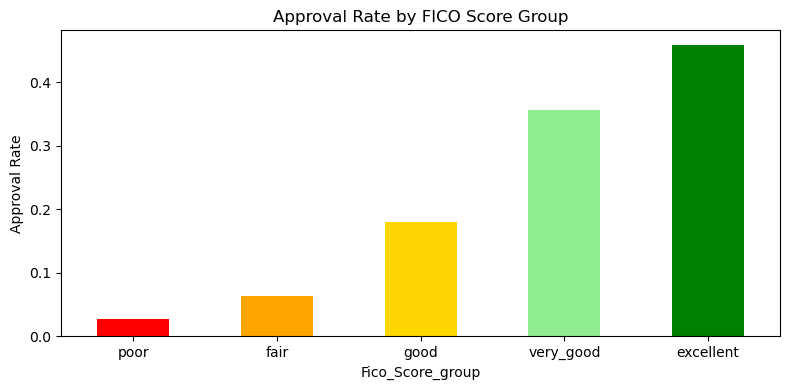

In [40]:
fico_rates.plot(kind="bar", color=["red","orange","gold","lightgreen","green"], figsize=(8,4))
plt.title("Approval Rate by FICO Score Group")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fico_approval_rate.png", dpi=150)
plt.show()

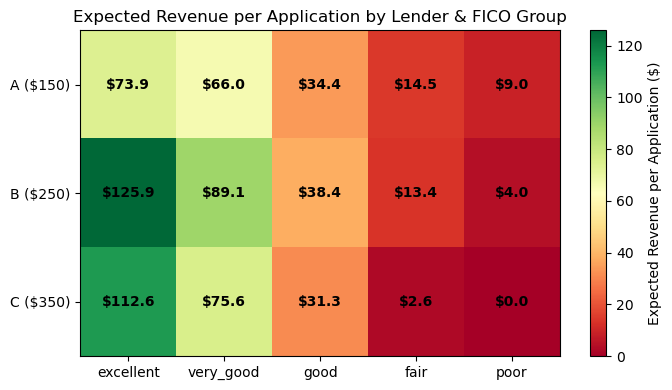

In [41]:
ev_heatmap = seg_rates.groupby(["Lender", "Fico_Score_group"])["EV"].mean().unstack()[fico_order[::-1]]
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(ev_heatmap.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(5))
ax.set_xticklabels(fico_order[::-1])
ax.set_yticks(range(3))
ax.set_yticklabels(["A ($150)", "B ($250)", "C ($350)"])
for i in range(3):
    for j in range(5):
        ax.text(j, i, f"${ev_heatmap.values[i,j]:.1f}", ha="center", va="center", fontsize=10, fontweight="bold")
plt.colorbar(im, label="Expected Revenue per Application ($)")
plt.title("Expected Revenue per Application by Lender & FICO Group")
plt.tight_layout()
plt.savefig("ev_heatmap.png", dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

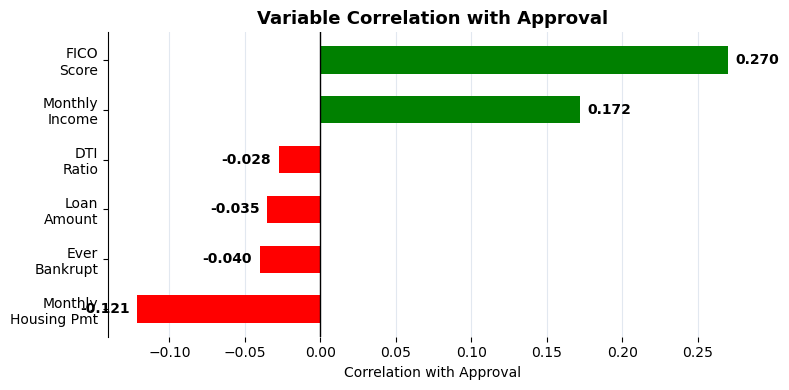

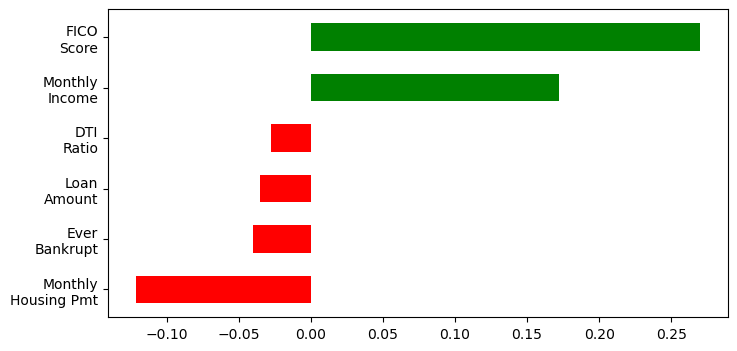

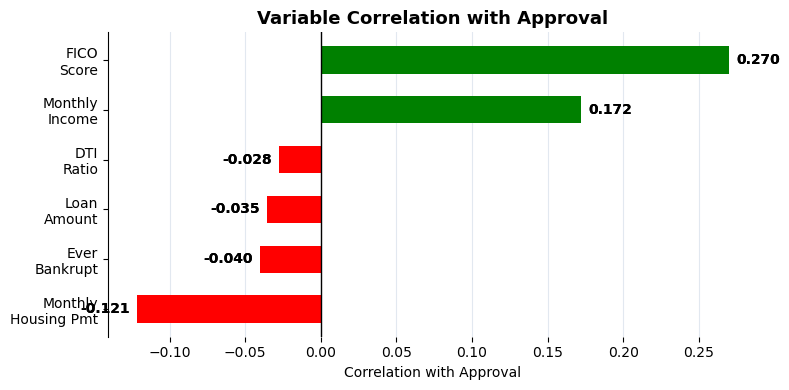

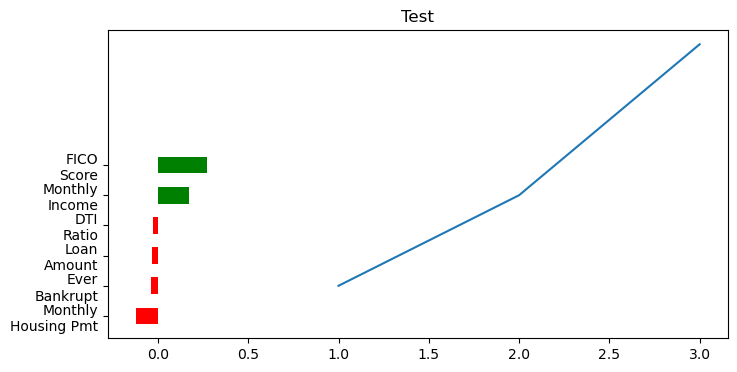

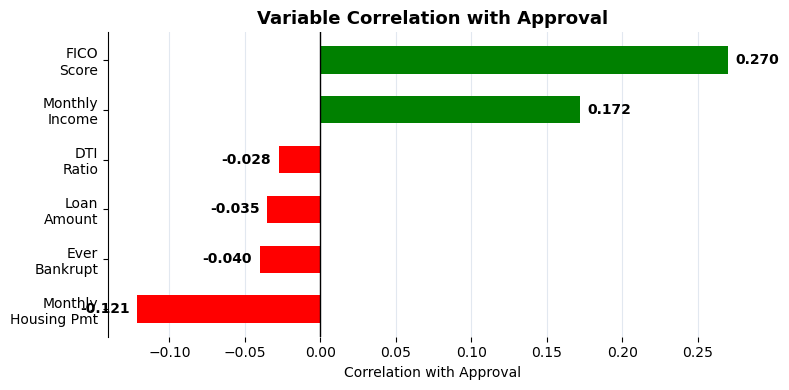

TclError: can't invoke "destroy" command: application has been destroyed

In [67]:
import numpy as np

numeric_cols = ["FICO_score", "Monthly_Gross_Income", "dti", 
                "Loan_Amount", "Ever_Bankrupt_or_Foreclose", "Monthly_Housing_Payment"]
corrs = df[numeric_cols].corrwith(df["Approved"]).sort_values()

labels = ["Monthly\nHousing Pmt", "Ever\nBankrupt", "Loan\nAmount", 
          "DTI\nRatio", "Monthly\nIncome", "FICO\nScore"]
colors = ["red" if v < 0 else "green" for v in corrs]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, corrs, color=colors, height=0.55)

for bar, val in zip(bars, corrs):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", ha=ha, fontsize=10, fontweight="bold")

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Correlation with Approval")
ax.set_title("Variable Correlation with Approval", fontsize=13, fontweight="bold")
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.xaxis.grid(True, color="#E2E8F0", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

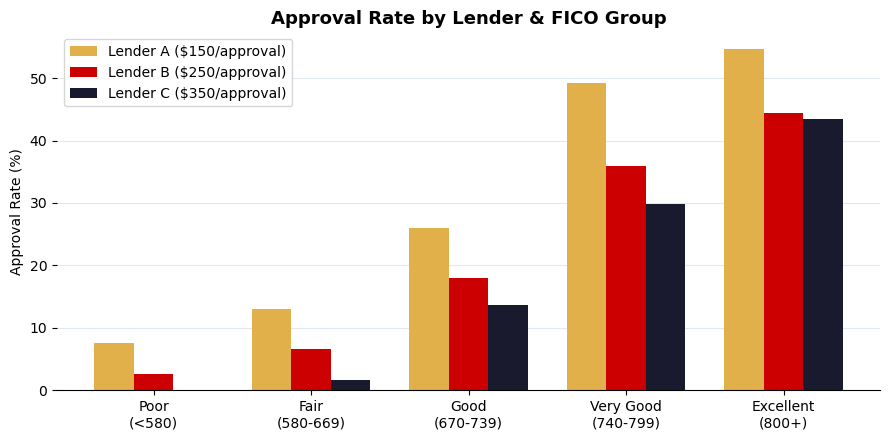

In [69]:
fico_order = ["poor", "fair", "good", "very_good", "excellent"]
labels = ["Poor\n(<580)", "Fair\n(580-669)", "Good\n(670-739)", "Very Good\n(740-799)", "Excellent\n(800+)"]

lender_fico = df.groupby(["Lender", "Fico_Score_group"])["Approved"].mean().unstack()[fico_order] * 100

x = np.arange(len(fico_order))
w = 0.25
lender_colors = ["#E2B04A", "#CC0000", "#1A1A2E"]
lender_bounties = ["$150/approval", "$250/approval", "$350/approval"]

fig, ax = plt.subplots(figsize=(9, 4.5))

for i, (lender, color, bounty) in enumerate(zip(["A", "B", "C"], lender_colors, lender_bounties)):
    ax.bar(x + (i - 1) * w, lender_fico.loc[lender], w,
           label=f"Lender {lender} ({bounty})", color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Approval Rate (%)")
ax.set_title("Approval Rate by Lender & FICO Group", fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

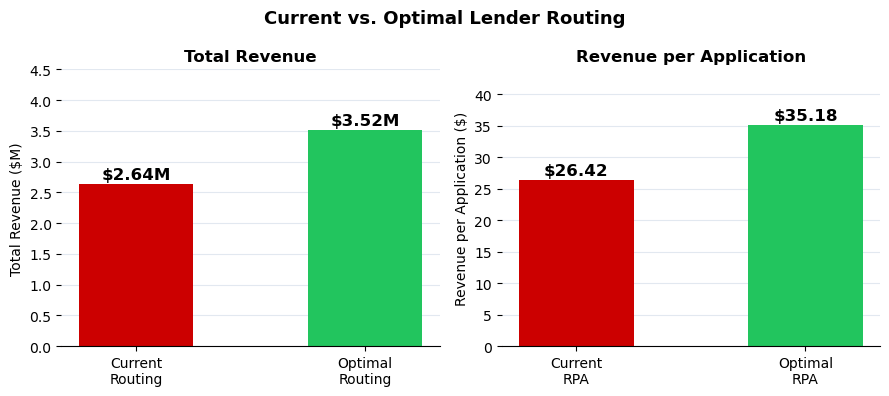

In [71]:
# Build approval rates by segment and calculate expected value
BOUNTY = {"A": 150, "B": 250, "C": 350}

seg_rates = (
    df.groupby(["Lender", "Fico_Score_group", "Employment_Status"])["Approved"]
    .mean()
    .reset_index()
    .rename(columns={"Approved": "Approval_Rate"})
)
seg_rates["EV"] = seg_rates.apply(lambda r: r["Approval_Rate"] * BOUNTY[r["Lender"]], axis=1)

# Find best lender per segment
ev_pivot = (
    seg_rates.pivot_table(
        index=["Fico_Score_group", "Employment_Status"],
        columns="Lender",
        values="EV"
    )
    .reset_index()
)
ev_pivot["best_ev"] = ev_pivot[["A", "B", "C"]].max(axis=1)

# Merge back and calculate revenues
df_opt = df.merge(
    ev_pivot[["Fico_Score_group", "Employment_Status", "best_ev"]],
    on=["Fico_Score_group", "Employment_Status"],
    how="left"
)

current_revenue = df["bounty"].sum()
current_rpa = current_revenue / len(df)
optimized_revenue = df_opt["best_ev"].sum()
optimized_rpa = optimized_revenue / len(df)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: Total Revenue
ax = axes[0]
bars = ax.bar(["Current\nRouting", "Optimal\nRouting"],
              [current_revenue / 1e6, optimized_revenue / 1e6],
              color=["#CC0000", "#22C55E"], width=0.5)
for bar, val in zip(bars, [current_revenue / 1e6, optimized_revenue / 1e6]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"${val:.2f}M", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Revenue ($M)")
ax.set_ylim(0, 4.5)
ax.set_title("Total Revenue", fontsize=12, fontweight="bold")
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

# Right: Revenue per Application
ax = axes[1]
bars = ax.bar(["Current\nRPA", "Optimal\nRPA"],
              [current_rpa, optimized_rpa],
              color=["#CC0000", "#22C55E"], width=0.5)
for bar, val in zip(bars, [current_rpa, optimized_rpa]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"${val:.2f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue per Application ($)")
ax.set_ylim(0, 44)
ax.set_title("Revenue per Application", fontsize=12, fontweight="bold")
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.suptitle("Current vs. Optimal Lender Routing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()